In [39]:
import pandas as pd
import numpy as np
import os
import zipfile
import re
import spacy
import seaborn as sns
import matplotlib.pyplot as plt 

from collections import defaultdict

## Téléchargement des données et preprocessing

In [2]:
data = pd.read_csv("data/metadonnees.csv")
data.head()

C:\Users\auran\AppData\Local\Temp\ipykernel_4608\3855839679.py:1: DtypeWarning: Columns (8,9,10,12,28,29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data/metadonnees.csv")


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-age-calcule,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations
0,EL009_L_1958_11_001_01_1_PF_01,1958-11-23,France;Élections législatives;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,maire;conseiller général,non mentionné,non mentionné,non mentionné,Parti radical,non mentionné,non
1,EL009_L_1958_11_001_01_1_PF_02,1958-11-23,France;Ve République;Élections législatives;As...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,conseiller municipal,non mentionné,non mentionné,prisonnier de guerre,Union pour la nouvelle République,non mentionné,non
2,EL009_L_1958_11_001_01_1_PF_03,1958-11-23,Élections législatives;France;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste français,non mentionné,non
3,EL009_L_1958_11_001_01_1_PF_04,1958-11-23,Élections législatives;France;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,35,entre 30 et 39 ans,greffier de paix,conseiller municipal;conseiller général,non mentionné,non mentionné,combattant,non mentionné,non mentionné,oui
4,EL009_L_1958_11_001_01_1_PF_05,1958-11-23,Ve République;Assemblée Nationale;Élections lé...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur;président Coopérative élevage,non mentionné,non mentionné,non mentionné,non mentionné,Centre national des indépendants et paysans,non mentionné,non


In [3]:
data.columns

Index(['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour',
       'cote', 'departement', 'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations'],
      dtype='object')

In [4]:
data["date"] = pd.to_datetime(data["date"])

data[["annee","mois","jour"]] = data["date"].apply(
    lambda x: pd.Series([x.year, x.month, x.day])
)
print("Nombre de professions par années :", data["annee"].value_counts().sort_index())

Nombre de professions par années : annee
1958    2774
1959       7
1962    2235
1965       8
1967    2871
1968    2872
1969       8
1973    3843
1974      13
1978    4830
1979       7
1981    3133
1986     740
1988    3551
1989      13
1993    5837
1995      11
1999      14
2002      18
2004      50
2007      13
2009      60
2012      12
2014      97
2019      13
Name: count, dtype: int64


In [5]:
# Export des professions de foi de l'année 1993
zip_path = "C:/Users/auran/OneDrive/Documents/ensae/3A/NLP/legislatives.zip"

docs = []

with zipfile.ZipFile(zip_path) as z:
    for file in z.namelist():
        if file.endswith(".txt"):
            with z.open(file) as f:
                text = f.read().decode("utf-8", errors="ignore")
                docs.append({"file": file, "text": text})

transcriptions = pd.DataFrame(docs)

transcriptions = transcriptions.assign(
    id=transcriptions["file"].str.extract(r'([^/]+)\.txt'),
    annee=transcriptions["file"].str.extract(r'text_files/(\d{4})')
)
transcriptions = transcriptions.drop(columns = ["file"])

transcriptions = transcriptions.merge(data[['id', 'titulaire-soutien']], on='id', how='left')


In [6]:
transcriptions.head()

,text,id,annee,titulaire-soutien
0,Département de Seine-Maritime - 12ème Circonsc...,EL196_L_1993_03_076_12_1_PF_01,1993,non mentionné
1,ELECTIONS LEGISLATIVES DU 21 MARS 1993\nREPUBL...,EL190_L_1993_03_024_02_1_PF_03,1993,non mentionné
2,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...,EL190_L_1993_03_017_01_1_PF_07,1993,Parti de la loi naturelle
3,Sciences Po / fonds CEVIPOF\nENTENTE DES ECOLO...,EL192_L_1993_03_050_02_1_PF_03,1993,Verts;Génération écologie
4,Sciences Po / fonds CEVIPOF\nLes Verts Confédé...,EL196_L_1993_03_079_04_1_PF_03,1993,Génération écologie;Verts


In [13]:
len(pd.unique(transcriptions['titulaire-soutien']))

308

On cherche à étudier les différentes méthodes d'adresse des candidats par partis politiques. On ne dispose ici que d'une variable 'titulaire-soutien' qui encode 308 différents courants. On cherche donc à créer une variable plus synthétique regroupant les différents grands partis de l'époque. Le code qui suit peut éventuellement être encore affiné.

In [17]:
# Création d'une autre variable d'affiliation politique plus synthétique

def classifier_parti(etiquette_brute):
    if pd.isna(etiquette_brute) or etiquette_brute == 'nan':
        return np.nan
    
    texte = str(etiquette_brute).lower()
    
    sous_partis = [p.strip() for p in texte.split(';')]
    
    # Drapeaux (Flags) pour détecter les familles présentes
    is_ps = False
    is_udf_rpr = False
    is_centre = False
    is_eco = False
    is_extreme_droite = False
    is_extreme_gauche = False
    is_regionaliste = False
    is_sans_etiquette = False
    
    # Mots-clés par famille
    keywords = {
        'ps': ['parti socialiste', 'ps', 'gauche', 'mouvement des citoyens', 'socialistes', 'socialiste'],

        'rpr' : ['rassemblement pour la république', 'rassemblement pour la republique', 'rpr'],

        'udf' : ['union pour la démocratie française', 'union pour la democratie francaise', 'udf'],
        
        'centre': ['mouvement démocrate', 'modem', 'centriste', 'centre des démocrates sociaux', 
                   'nouveau centre', 'les centristes', 'agir', 'alliance centriste', 
                   'centre', 'mouvement des réformateurs'],
        
        'ecolo': ['vert', 'verts', 'écologie', 'ecolo', 'génération écologie', 'nature et animaux', 
                  'région verte', 'écologiste', 'biosphère', 'generation ecologie', 'écologie les verts',
                  'ecologie les verts', 'ecologie'],
        
        'extreme_droite': ['front national', 'fn', 'mouvement national', 'jeunesse nationaliste', 
                           'alsace d\'abord', 'identitaire', 'patriote', "trop d'immigrés la france aux français"],
        
        'extreme_gauche': ['lutte ouvrière', 'ligue communiste', 'npa', 'nouveau parti anticapitaliste',
                           'parti des travailleurs', 'trotskyste', 'alternative libertaire',
                           'parti communiste français', 'ligue communiste révolutionnaire', 'communistes',
                           'communiste'],
        
        'regionaliste': ['corsica', 'breton', 'occitan', 'alsacien', 'basque', 'euskal', 'unitat catalana',
                         'union démocratique bretonne', 'udb', 'autonomie', 'indépendantiste', 'abertzale',
                         'corse', 'corsa', 'eusko alkartasuna', 'esquerra republicana de catalunya'],
        
        'sans_etiquette': ['sans étiquette', 'divers', 'indépendant', 'apolitique', 'aucun parti', 
                           'non mentionné', 'non inscrit', 'hors des partis', 'société civile', 'libre', 'nan',
                           'sans parti politique', 'aucune formation politique']
    }
    # Analyse de chaque sous-parti
    for parti in sous_partis:
        # Vérification Gauche
        if any(k in parti for k in keywords['ps']):
            is_ps = True
        # Vérification Droite
        if any(k in parti for k in keywords['rpr']) or any(k in parti for k in keywords['udf']):
            is_udf_rpr = True
        # Vérification Centre
        if any(k in parti for k in keywords['centre']):
            is_centre = True
        # Vérification Écologie
        if any(k in parti for k in keywords['ecolo']):
            is_eco = True
        # Vérification Extrême Droite
        if any(k in parti for k in keywords['extreme_droite']):
            is_extreme_droite = True
        # Vérification Extrême Gauche
        if any(k in parti for k in keywords['extreme_gauche']):
            is_extreme_gauche = True
        # Vérification Régionaliste
        if any(k in parti for k in keywords['regionaliste']):
            is_regionaliste = True
        # Vérification Sans étiquette
        if any(k in parti for k in keywords['sans_etiquette']):
            is_sans_etiquette = True

    if is_eco and is_extreme_gauche : 
        return 'Extrême-Gauche'  # 'Ecologiste-Extreme-Gauche

    if is_extreme_droite: return 'Extrême-Droite'
    if is_extreme_gauche: return 'Extrême-Gauche'
    if is_ps: return 'Parti socialiste - Gauche'
    if is_udf_rpr: return 'UDF/RPR'
    if is_centre: return 'Centre'
    if is_eco: return 'Ecologiste'
    if is_regionaliste: return 'Régionaliste'
    if is_sans_etiquette: return 'Sans étiquette / Divers'
    
    # Si rien n'a matché (cas rares ou nouveaux partis)
    return 'Autre / Non classé'

transcriptions['parti_synthetique'] =transcriptions['titulaire-soutien'].apply(classifier_parti)

transcriptions[['titulaire-soutien', 'parti_synthetique']][40:60]

,titulaire-soutien,parti_synthetique
40,indépendant;hors des partis politiques,Sans étiquette / Divers
41,Rassemblement pour la République;Union pour la...,UDF/RPR
42,Front national,Extrême-Droite
43,Lutte ouvrière,Extrême-Gauche
44,Front national,Extrême-Droite
45,Front national,Extrême-Droite
46,Union des indépendants,Sans étiquette / Divers
47,indépendant,Sans étiquette / Divers
48,NaN,NaN
49,Mouvement des réformateurs;Solidarités;Politiq...,Centre


In [19]:
non_classes = transcriptions[transcriptions['parti_synthetique'] == 'Autre / Non classé']

# pd.unique(non_classes['titulaire-soutien'])

In [20]:
print("Nombre de candidats par partis : ", transcriptions['parti_synthetique'].value_counts().sort_index())

Nombre de candidats par partis :  parti_synthetique
Autre / Non classé            306
Centre                        121
Ecologiste                   1084
Extrême-Droite                659
Extrême-Gauche                952
Parti socialiste - Gauche     481
Régionaliste                   22
Sans étiquette / Divers      1243
UDF/RPR                       969
Name: count, dtype: int64


On compte beaucoup d'écologistes quand même : est-ce que tel était le cas ou est-ce que j'ai fait quelque chose de biaisé ?

In [21]:
pd.set_option('display.max_colwidth', None)
extrait = transcriptions.sample()

In [22]:
def nettoyage_profession_foi(texte):

    if not isinstance(texte, str):
        return ""
    
    texte = re.sub(r'[\u2600-\u26FF\u2700-\u27BF\u25A0-\u25FF]', ' ', texte)
    texte = re.sub(r'[A-Z]{4,}\s[A-Z]{4,}', '', texte) 

    # Enlever les 'ELECTIONS LEGISLATIVES'
    texte = re.sub(r'ÉLECTIONS\s[A-Z\s]+-\s[A-Z]+\s\d{4}', '', texte, flags=re.IGNORECASE)

    # Suppression des noms de candidats/suppléants
    texte = re.sub(r'\n?[A-Z][a-z]+\s+[A-Z]{2,}\s+(?:candidat|suppléant)[^\n]*', '', texte) # Suppression des noms de candidats/suppléants
    
    # Suppression de la mention 'Sciences Po/ fonds CEVIPOF'
    texte = re.sub(r'.*?(?:Sciences Po|fonds CEVIPOF|Archives).*?$', '', texte, flags=re.MULTILINE | re.IGNORECASE)
    
    # Nettoyage des espaces et retours à la ligne
    texte = re.sub(r'\n{3,}', '\n\n', texte) 
    texte = re.sub(r'\s+', ' ', texte) 
    
    # Suppression des césures
    texte = re.sub(r'(\w+)-\s+(\w+)', r'\1\2', texte)

    texte = texte.lower()
    
    return texte.strip()


On ne veut pas nécessairement retirer les stopwords, car l'on veut à terme regarder dans quelle mesure les candidats s'adressent à leurs électeurs, évoquent également d'autres responsables politiques. En particulier, les pronoms personnels ("vous"), les déterminants possessifs ("vos", "nos") sont importants dans ce cas.

In [23]:
# Test 
extrait_nettoye = nettoyage_profession_foi(extrait['text'].iloc[0])
print(extrait_nettoye)

elections législatives - scrutins des 21 et 28 mars 1993 - département du puy-de-dôme - 6e circonscription roland gourves 46 ans conseiller municipal de riom enseignant-chercheur en mécanique des sols claudine couturier 39 ans, 1 enfant porte-parole des verts 63 présidente d'une association de défense de l'environnement (chaîne des puys) professeur de français roland gourvès claudine couturier l'entente des ecologistes veut promouvoir une politique inventive, mais réaliste. la croissance stagne et rien ne nous permet d'espérer son évolution à terme. une reprise importante se ferait nécessairement au détriment de nos conditions d'environnement surconsommation d'énergie, dégradation des espaces et des paysages). la croissance doit s'inscrire dans la réalisation de biens durables moins consommateurs d'énergie et d'espace. elle doit s'appuyer sur la redistribution du temps de travail et des revenus. plutôt qu'un catalogue de promesses quelques exemples montreront le sens de l'action que no

In [ ]:
# Prend près de 2min : il faudrait peut-être mieux faire une boucle for plutôt qu'un apply
transcriptions['texte_nettoye'] = transcriptions['text'].apply(nettoyage_profession_foi)

## Analyse des pronoms

In [24]:
# Tokenization
nlp = spacy.load("fr_core_news_sm")  # Au préalable, télécharger : python -m spacy download fr_core_news_sm

def tokenizer_et_pos(texte_propre):
    """Prend un texte déjà nettoyé et en minuscules, retourne tokens et POS"""
    doc = nlp(texte_propre)
    return [(token.text, token.pos_) for token in doc if not token.is_space]

# Petit test
token_extrait = tokenizer_et_pos(extrait_nettoye)

print(token_extrait[:15])

[('elections', 'NOUN'), ('législatives', 'ADJ'), ('-', 'PUNCT'), ('scrutins', 'ADJ'), ('des', 'ADP'), ('21', 'PRON'), ('et', 'CCONJ'), ('28', 'NUM'), ('mars', 'NOUN'), ('1993', 'NUM'), ('-', 'PUNCT'), ('département', 'ADV'), ('du', 'ADP'), ('puy-de-dôme', 'NOUN'), ('-', 'PUNCT')]


In [ ]:
textes = transcriptions['texte_nettoye'].tolist()
resultats = []

for doc in nlp.pipe(textes, batch_size=50, disable=["tagger", "parser", "ner"]):

    comptes = {'je': 0, 'nous': 0, 'vous': 0, 'on': 0, 'total_pronoms': 0}
    total_mots = 0
    
    for token in doc:
        if token.is_space or token.is_punct:
            continue
        total_mots += 1
        
        if token.pos_ == "PRON":

            lemme = token.text.lower()
            
            # Mapping intelligent basé sur le lemme
            if lemme in ['je', 'moi', 'me', "m'", "mes", "ma"]:
                comptes['je'] += 1
            elif lemme in ['nous', 'notre', 'nos', "nôtres"]: 
                comptes['nous'] += 1
            elif lemme in ['vous', 'votre', 'vos', "vôtres"]:
                comptes['vous'] += 1
            elif lemme == 'on':
                comptes['on'] += 1
            
            comptes['total_pronoms'] += 1

    ratios = {}
    for key in ['je', 'nous', 'vous', 'on']:
        ratios[f'{key}_p1000'] = (comptes[key] / total_mots * 1000) if total_mots > 0 else 0
        
    total_je_nous = comptes['je'] + comptes['nous']
    ratios['ratio_je_nous'] = comptes['je'] / total_je_nous if total_je_nous > 0 else 0

    total_je_vous = comptes['je'] + comptes['vous']
    ratios['ratio_je_vous'] = comptes['je'] / total_je_vous if total_je_vous > 0 else 0
    
    resultats.append(ratios)


In [34]:
pronoms_stats = pd.DataFrame(resultats, index=transcriptions['texte_nettoye'].index)
transcriptions_analysis = pd.concat([transcriptions, pronoms_stats], axis=1)
transcriptions_analysis = transcriptions_analysis.drop(columns = ['text', 'annee', 'titulaire-soutien', 'texte_nettoye'])
transcriptions_analysis.head()

,id,parti_synthetique,je_p1000,nous_p1000,vous_p1000,on_p1000,ratio_je_nous,ratio_je_vous
0,EL196_L_1993_03_076_12_1_PF_01,Sans étiquette / Divers,11.029412,2.450980,8.578431,1.22549,0.818182,0.562500
1,EL190_L_1993_03_024_02_1_PF_03,Sans étiquette / Divers,8.836524,1.472754,8.836524,0.00000,0.857143,0.500000
2,EL190_L_1993_03_017_01_1_PF_07,Autre / Non classé,2.424242,4.848485,4.848485,0.00000,0.333333,0.333333
3,EL192_L_1993_03_050_02_1_PF_03,Ecologiste,5.272408,0.000000,1.757469,0.00000,1.000000,0.750000
4,EL196_L_1993_03_079_04_1_PF_03,Ecologiste,0.000000,0.000000,5.917160,0.00000,0.000000,0.000000


In [36]:
cols_scores = ['je_p1000', 'nous_p1000', 'vous_p1000', 'on_p1000', 'ratio_je_nous', 'ratio_je_vous']
agg_stats = transcriptions_analysis.groupby('parti_synthetique')[cols_scores].agg(['mean', 'std']).reset_index()
agg_stats.columns = [f"{col[0]}_{col[1]}" if col[1] != '' else col[0] for col in agg_stats.columns]

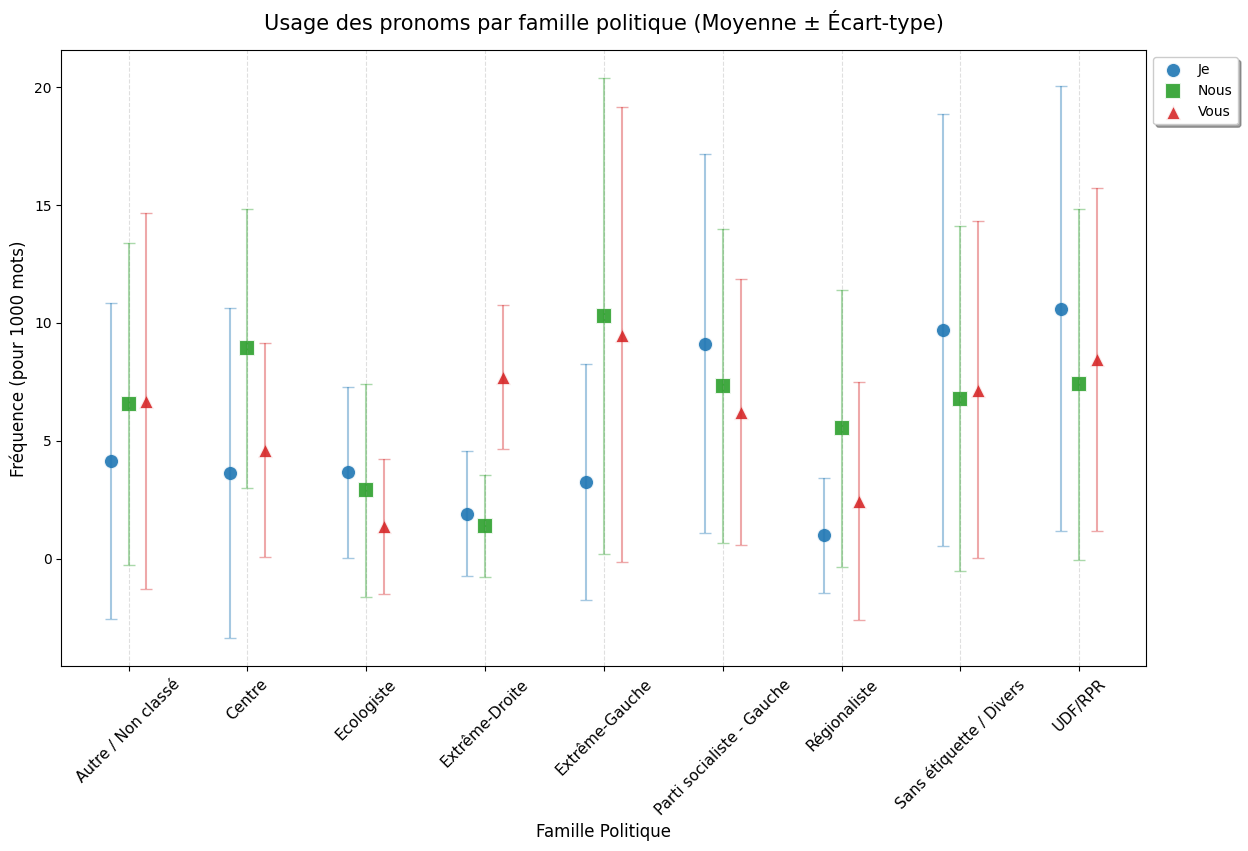

In [38]:
df = agg_stats.copy()
partis = df['parti_synthetique']
y_pos = np.arange(len(partis))  

plt.figure(figsize=(14, 8))

offset = 0.15 

plt.scatter(
    y_pos - offset, 
    df['je_p1000_mean'], 
    s=120,                # Taille des points
    c='#1f77b4',          # Couleur Bleu
    marker='o',           # Cercle
    label='Je', 
    edgecolors='white',   # Bordure blanche pour détacher du fond
    linewidth=1.5,
    alpha=0.9
)
# Barres d'erreur pour Je
plt.errorbar(y_pos - offset, df['je_p1000_mean'], yerr=df['je_p1000_std'], 
             fmt='none', ecolor='#1f77b4', alpha=0.4, capsize=4)

plt.scatter(
    y_pos, 
    df['nous_p1000_mean'], 
    s=120, 
    c='#2ca02c', 
    marker='s',           # Carré
    label='Nous', 
    edgecolors='white', 
    linewidth=1.5,
    alpha=0.9
)
# Barres d'erreur pour Nous
plt.errorbar(y_pos, df['nous_p1000_mean'], yerr=df['nous_p1000_std'], 
             fmt='none', ecolor='#2ca02c', alpha=0.4, capsize=4)


plt.scatter(
    y_pos + offset, 
    df['vous_p1000_mean'], 
    s=120, 
    c='#d62728', 
    marker='^',           # Triangle
    label='Vous', 
    edgecolors='white', 
    linewidth=1.5,
    alpha=0.9
)
# Barres d'erreur pour Vous
plt.errorbar(y_pos + offset, df['vous_p1000_mean'], yerr=df['vous_p1000_std'], 
             fmt='none', ecolor='#d62728', alpha=0.4, capsize=4)

plt.title("Usage des pronoms par famille politique (Moyenne ± Écart-type)", fontsize=15, pad=15)
plt.xlabel("Famille Politique", fontsize=12)
plt.ylabel("Fréquence (pour 1000 mots)", fontsize=12)

# Remplacement des ticks numériques par les noms des partis
plt.xticks(y_pos, partis, fontsize=11, rotation = 45)

# Grille horizontale uniquement pour aider à lire les valeurs
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Légende flottante pour ne pas gêner les points
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True, shadow=True)


plt.show()

Faire de meilleures stats desc

Idées : étudier les verbes (actions/états) employés dans le discours.
Quelles fonctions ont les 'nous', les 'vous' dans la phrase ? (sujet, COD, autre)

### Identification de la fonction dans la phrase 

Les quelques cellules ci-dessous tentent d'identifier la fonction des pronoms 'je', 'nous', 'vous' lorsqu'ils sont utilisés (sujet VS objet), ainsi que le type de verbe qui les succède ou précède (action VS état).

In [40]:
# Verbes statifs
VERBES_ETAT = {'être', 'paraître', 'sembler', 'demeurer', 'rester', 'devenir', 'voir', 'vivre'
               'devoir', 'pouvoir', 'vouloir', 'falloir', 'savoir', 'croire', 'penser', 'appeler'}

VERBES_MODAUX = {'devoir', 'pouvoir', 'vouloir', 'aller', 'faire', 'laisser', 'sembler', 'paraître'}


In [ ]:
# Prend environ 3 min 
textes = transcriptions['texte_nettoye'].tolist()

results = []

for doc in nlp.pipe(textes, batch_size=50, disable=["ner"]):
    
    stats = {'je': defaultdict(int), 'nous': defaultdict(int), 'vous': defaultdict(int)}
    mapping_pronom = {
        'je': ['je', "j'", 'moi', 'me', "m'"],
        'nous': ['nous'],
        'vous': ['vous']
    }

    for token in doc:
        if token.is_space or token.is_punct: 
            continue
        
        pronom_type = None
        if token.pos_ == "PRON":
            for p_type, formes in mapping_pronom.items():
                if token.text.lower() in formes or token.lemma_.lower() in formes:
                    pronom_type = p_type
                    break
        
        if pronom_type:
            verbe = None
            fonction = None
            
            if token.dep_ in ("nsubj", "nsubjpass"):
                fonction = "sujet"
                if token.head.pos_ in ("VERB", "AUX"): 
                    verbe_cible = token.head
            elif token.dep_ in ("dobj", "obj", "iobj", "obl"):
                fonction = "objet"
                if token.head.pos_ in ("VERB", "AUX"): 
                    verbe_cible = token.head

            lemme_tete = verbe_cible.lemma_.lower() # Ex type : Nous devons agir : on veut identifier agir et non devoir
            if lemme_tete in VERBES_MODAUX: # {'devoir', 'pouvoir', 'vouloir', 'aller', 'faire'}
                for child in verbe_cible.children:
                    if child.pos_ == "VERB":
                        verbe = child # On remplace le modal par le verbe enfant
                        break
            else :
                verbe = verbe_cible
                
            if verbe:
                v_lem = verbe.lemma_.lower()
                type_v = "etat" if v_lem in VERBES_ETAT else "action"
                stats[pronom_type][f"{fonction}_{type_v}"] += 1
                stats[pronom_type][f"{fonction}"] +=1
                stats[pronom_type][f"{type_v}"] +=1

    row = {}
    for p in ['je', 'nous', 'vous']:
        for k, v in stats[p].items():
            row[f"{p}_{k}"] = v
    
    for p in ['je', 'nous', 'vous']:
        for f in ['sujet', 'objet']:
            for t in ['action', 'etat']:
                key = f"{p}_{f}_{t}"
                if key not in row: 
                    row[key] = 0
                
    results.append(row)

df_structure = pd.DataFrame(results)

# Concaténation avec les infos originales
transcriptions_structure_test = pd.concat([transcriptions[['id', 'parti_synthetique']], df_structure], axis=1)

In [45]:
transcriptions_structure_test.head()

,id,parti_synthetique,je_objet_action,je_objet,je_action,je_sujet_action,je_sujet,je_None_action,je_None,nous_sujet_action,...,nous_sujet_etat,nous_objet_action,nous_objet_etat,vous_objet_etat,je_etat,vous_None_etat,nous_etat,nous_objet,je_None_etat,nous_None_etat
0,EL196_L_1993_03_076_12_1_PF_01,Sans étiquette / Divers,1,1.0,16.0,13,13.0,2.0,2.0,1,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,EL190_L_1993_03_024_02_1_PF_03,Sans étiquette / Divers,0,NaN,6.0,4,6.0,2.0,2.0,1,...,0,0,0,0,2.0,1.0,NaN,NaN,NaN,NaN
2,EL190_L_1993_03_017_01_1_PF_07,Autre / Non classé,0,NaN,2.0,1,1.0,1.0,1.0,3,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,EL192_L_1993_03_050_02_1_PF_03,Ecologiste,1,1.0,3.0,1,1.0,1.0,1.0,0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,EL196_L_1993_03_079_04_1_PF_03,Ecologiste,0,NaN,NaN,0,NaN,NaN,NaN,0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
transcriptions_structure_test.columns

Index(['id', 'parti_synthetique', 'je_objet_action', 'je_objet', 'je_action',
       'je_sujet_action', 'je_sujet', 'je_None_action', 'je_None',
       'nous_sujet_action', 'nous_sujet', 'nous_action', 'nous_None_action',
       'nous_None', 'vous_sujet_action', 'vous_sujet', 'vous_action',
       'vous_objet_action', 'vous_objet', 'vous_sujet_etat', 'vous_etat',
       'vous_None_action', 'vous_None', 'je_sujet_etat', 'je_objet_etat',
       'nous_sujet_etat', 'nous_objet_action', 'nous_objet_etat',
       'vous_objet_etat', 'je_etat', 'vous_None_etat', 'nous_etat',
       'nous_objet', 'je_None_etat', 'nous_None_etat'],
      dtype='object')

In [ ]:
cols_scores = ['je_objet_action', 'je_objet', 'je_action',
       'je_sujet_action', 'je_sujet', 'je_None_action', 'je_None',
       'nous_sujet_action', 'nous_sujet', 'nous_action', 'nous_None_action',
       'nous_None', 'vous_sujet_action', 'vous_sujet', 'vous_action',
       'vous_objet_action', 'vous_objet', 'vous_sujet_etat', 'vous_etat',
       'vous_None_action', 'vous_None', 'je_sujet_etat', 'je_objet_etat',
       'nous_sujet_etat', 'nous_objet_action', 'nous_objet_etat',
       'vous_objet_etat', 'je_etat', 'vous_None_etat', 'nous_etat',
       'nous_objet', 'je_None_etat', 'nous_None_etat']  # A CHANGER

agg_stats = transcriptions_structure_test.groupby('parti_synthetique')[cols_scores].agg(['sum']).reset_index()
agg_stats.columns = [f"{col[0]}_{col[1]}" if col[1] != '' else col[0] for col in agg_stats.columns]

In [47]:
agg_stats

,parti_synthetique,je_objet_action_sum,je_objet_sum,je_sujet_action_sum,je_sujet_sum,je_None_action_sum,je_None_sum,nous_sujet_action_sum,nous_sujet_sum,nous_None_action_sum,...,je_sujet_etat_sum,je_objet_etat_sum,nous_sujet_etat_sum,nous_objet_action_sum,nous_objet_etat_sum,vous_objet_etat_sum,vous_None_etat_sum,nous_objet_sum,je_None_etat_sum,nous_None_etat_sum
0,Autre / Non classé,78,80.0,490,561.0,183.0,197.0,979,1085.0,244.0,...,71,2,106,151,22,0,37.0,173.0,14.0,16.0
1,Centre,28,28.0,195,219.0,61.0,66.0,163,220.0,159.0,...,24,0,57,34,10,0,8.0,44.0,5.0,13.0
2,Ecologiste,108,108.0,1307,1469.0,244.0,258.0,1356,1491.0,231.0,...,162,0,135,182,71,5,25.0,253.0,14.0,18.0
3,Ecologiste-Extreme-Gauche,10,10.0,46,54.0,9.0,10.0,38,45.0,14.0,...,8,0,7,3,0,0,3.0,3.0,1.0,0.0
4,Extrême-Droite,32,32.0,779,845.0,114.0,117.0,592,615.0,61.0,...,66,0,23,39,0,6,80.0,39.0,3.0,5.0
5,Extrême-Gauche,292,296.0,1489,1782.0,347.0,404.0,4497,5382.0,2084.0,...,293,4,885,2229,251,49,145.0,2480.0,57.0,45.0
6,Parti socialiste - Gauche,300,303.0,2210,2515.0,582.0,612.0,1367,1582.0,356.0,...,305,3,215,184,67,19,78.0,251.0,30.0,34.0
7,Régionaliste,2,2.0,6,10.0,2.0,2.0,68,75.0,13.0,...,4,0,7,7,1,1,0.0,8.0,0.0,0.0
8,Sans étiquette / Divers,949,960.0,4764,5506.0,1174.0,1263.0,2691,3099.0,580.0,...,742,11,408,578,96,53,141.0,674.0,89.0,71.0
9,UDF/RPR,741,751.0,3355,3832.0,949.0,1001.0,2159,2362.0,395.0,...,477,10,203,415,79,31,75.0,494.0,52.0,36.0


Statistiques descriptives (à faire)